# 🚦 도로 시설물 파손 탐지 - YOLOv11 Segmentation 학습
**Colab A100 | Ultralytics YOLOv11 | Instance Segmentation**

- 데이터: AI Hub 보행 안전 도로 시설물
- 모델: YOLOv11m-seg
- 라벨: polygon → YOLO Segmentation 포맷 변환 완료


In [ ]:
# 패키지 설치
!pip install -q ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 43.1/235.7 GB disk)


In [ ]:
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [10]:
from google.colab import drive
drive.mount('/content/drive')

# 공유된 폴더는 '공유 문서함'에 있음
# DATASET_PATH = '/content/drive/MyDrive/../Shareddrives/...'
# 또는
# DATASET_PATH = '/content/drive/Shareddrives/yolo_dataset_seg'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
DATASET_PATH = '/content/drive/MyDrive/yolo_dataset_seg'  # ← Drive 내 경로로 수정
YAML_PATH    = f'{DATASET_PATH}/dataset.yaml'

assert os.path.exists(YAML_PATH), f'dataset.yaml 없음: {YAML_PATH}'
print('✅ 데이터셋 확인 완료')

import yaml
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)
print(f'클래스 수: {cfg["nc"]}')
for i, name in enumerate(cfg['names']):
    print(f'  {i:2d}: {name}')

In [ ]:
# dataset.yaml path 업데이트
import yaml
with open(YAML_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

cfg['path'] = DATASET_PATH

with open(YAML_PATH, 'w') as f:
    yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)

print('✅ dataset.yaml 경로 업데이트 완료')

In [ ]:
from ultralytics import YOLO

# YOLOv11 seg 모델 선택
# yolo11n-seg: 가장 빠름 / yolo11m-seg: 균형 / yolo11l-seg: 정확도 높음
MODEL_SIZE = 'yolo11m-seg'

model = YOLO(f'{MODEL_SIZE}.pt')  # pretrained COCO weights
print(f'✅ {MODEL_SIZE} 로드 완료')

In [ ]:
!pip install -q albumentations
import albumentations as A

# 커스텀 augmentation 정의
custom_aug = [
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),   # 블러 (점자 올록볼록 안보이는 상황)
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3), # 노이즈 (저화질 카메라)
    A.ImageCompression(quality_lower=60, quality_upper=95, p=0.3), # JPEG 압축
]

In [ ]:
# 중단 후 이 셀 실행 (20분 정도 소요)
!cp -r /content/drive/MyDrive/yolo_dataset_seg /content/yolo_dataset_seg

In [ ]:
# 2. DATASET_PATH를 로컬 경로로 변경
DATASET_PATH = '/content/yolo_dataset_seg'
YAML_PATH = f'{DATASET_PATH}/dataset.yaml'

# yaml path도 업데이트
import yaml
with open(YAML_PATH, 'r') as f:
    cfg = yaml.safe_load(f)
cfg['path'] = DATASET_PATH
with open(YAML_PATH, 'w') as f:
    yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)
print('✅ YAML 경로 업데이트')

In [ ]:
ls /content/yolo_dataset_seg/

In [ ]:
# # 학습 시작
# results = model.train(
#     data=YAML_PATH,
#     epochs=100,
#     imgsz=640,
#     batch=32,           # A100 80GB 기준, OOM이면 16으로 줄이기
#     workers=4,
#     device=0,
#     project='/content/drive/MyDrive/yolo_runs',
#     name='road_facility_seg_v1',
#     exist_ok=True,

#     # 학습 설정
#     optimizer='AdamW',
#     lr0=0.001,
#     lrf=0.01,
#     warmup_epochs=3,
#     weight_decay=0.0005,

#     # Augmentation
#     hsv_h=0.015,
#     hsv_s=0.7,
#     hsv_v=0.4,
#     flipud=0.0,
#     fliplr=0.5,
#     mosaic=1.0,
#     mixup=0.1,
#     erasing=0.2,       # 랜덤 영역 지우기 (0~1), 일부 가려진 상황 대응

#     # 화질 저하 대응 추가
#     augmentations=custom_aug,

#     # 저장
#     save=True,
#     save_period=10,
#     val=True,
#     plots=True,
# )

# print('✅ 학습 완료!')

In [ ]:
from ultralytics import YOLO

LAST_PT = '/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/last.pt'

# 이어서 학습
model = YOLO(LAST_PT)
results = model.train(resume=True)

WARNING ⚠️ Custom Albumentations transforms were used in the original training run but are not being restored. To preserve custom augmentations when resuming, you need to pass the 'augmentations' parameter again to get expected results. Example: 
model.train(resume=True, augmentations=[GaussianBlur(p=0.3, blur_limit=(3, 7), sigma_limit=(0.5, 3.0)), GaussNoise(p=0.3, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)), ImageCompression(p=0.3, compression_type='jpeg', quality_range=(99, 100))])
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[GaussianBlur(p=0.3, blur_limit=(3, 7), sigma_limit=(0.5, 3.0)), GaussNoise(p=0.3, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)), ImageCompression(p=0.3, compression_type='jpeg', quality_range=(99, 100))], auto_augment=randaugment, batch=32, 

KeyboardInterrupt: 

In [ ]:
# 테스트셋 평가
best_model = YOLO('/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/best.pt')
metrics = best_model.val(data=YAML_PATH, split='test')

print('\n=== 테스트셋 결과 (Box) ===')
print(f'mAP50:     {metrics.box.map50:.4f}')
print(f'mAP50-95:  {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall:    {metrics.box.mr:.4f}')

print('\n=== 테스트셋 결과 (Mask) ===')
print(f'mAP50:     {metrics.seg.map50:.4f}')
print(f'mAP50-95:  {metrics.seg.map:.4f}')
print(f'Precision: {metrics.seg.mp:.4f}')
print(f'Recall:    {metrics.seg.mr:.4f}')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m-seg summary (fused): 139 layers, 22,343,022 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 6.1±1.8 MB/s, size: 7566.0 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1-bjst2tVzRxRJRwfWPBat_Ibk06qozP1/yolo_dataset_seg/labels/test.cache... 744 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 744/744 208.0Mit/s 0.0s
val: /content/drive/.shortcut-targets-by-id/1-bjst2tVzRxRJRwfWPBat_Ibk06qozP1/yolo_dataset_seg/images/test/1_01_0_1_1_1_20210722_0000019499.jpg: corrupt JPEG restored and saved
val: /content/drive/.shortcut-targets-by-id/1-bjst2tVzRxRJRwfWPBat_Ibk06qozP1/yolo_dataset_seg/images/test/1_01_0_1_1_1_20210812_0000200412.jpg: corrupt JPEG restored and saved
val: /content/drive/.shortcut-targets-by-id/1-bjst2tVzRxRJRwfWPBat_Ibk06qozP1/yolo_dataset_seg/images/test/1_01_0_1_1_1_20210812_0000221297.jpg: corrupt JPEG restored and sav

In [11]:
# 드라이브에서 Colab 로컬로 복사
# !cp -r /content/drive/MyDrive/finetuning_yolov11 /content/finetuning_block

!cp -r /content/drive/MyDrive/finetuning_v2_yolov11/finetuing_v2 /content/finetuning_block_v2

In [12]:
# import yaml
# with open('/content/finetuning_block/data.yaml', 'r') as f:
#     cfg = yaml.safe_load(f)
# cfg['path'] = '/content/finetuning_block'
# with open('/content/finetuning_block/data.yaml', 'w') as f:
#     yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)
# print('✅ yaml 경로 업데이트')

import yaml
with open('/content/finetuning_block_v2/data.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
cfg['path'] = '/content/finetuning_block_v2'
with open('/content/finetuning_block_v2/data.yaml', 'w') as f:
    yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)
print('✅ yaml 경로 업데이트')

✅ yaml 경로 업데이트


In [13]:
from ultralytics import YOLO

# 기존 best.pt 로드
model = YOLO('/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/best.pt')

model.train(
    data='/content/finetuning_block/data.yaml',
    epochs=30,          # 파인튜닝은 적게
    imgsz=640,
    batch=16,           # 데이터 적으니 줄이기
    workers=4,
    device=0,
    # project='/content/drive/MyDrive/yolo_fine_runs',
    project='/content/drive/MyDrive/yolo_fine_v2_runs',
    name='road_facility_finetune_v1',
    exist_ok=True,

    # 파인튜닝 핵심: 학습률 낮게
    lr0=0.0001,         # 기존의 1/10
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=0.0005,

    # Augmentation은 가볍게
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.5,         # 파인튜닝은 낮게
    mixup=0.0,          # 파인튜닝은 끄기

    save=True,
    save_period=5,
    val=True,
    plots=True,
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/finetuning_block/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/best.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=road_facility_finetune_v1,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([6, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e493a727bf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [ ]:
# 클래스별 성능 확인
import pandas as pd, yaml

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

df_box = pd.DataFrame({
    'class':       cfg['names'],
    'Box_AP50':    metrics.box.ap50,
    'Box_AP50-95': metrics.box.ap,
    'Mask_AP50':   metrics.seg.ap50,
    'Mask_AP50-95':metrics.seg.ap,
}).sort_values('Mask_AP50', ascending=False)

print(df_box.to_string(index=False))

           class  Box_AP50  Box_AP50-95  Mask_AP50  Mask_AP50-95
         점자블럭_정상  0.966138     0.934365   0.966138      0.948518
  Bollard_대리석_정상  0.954625     0.948600   0.954625      0.862122
  Bollard_대리석_불량  0.949131     0.922494   0.949131      0.863038
 Bollard_탄성고무_정상  0.912967     0.888212   0.912967      0.769039
 Bollard_탄성고무_불량  0.887952     0.819484   0.887952      0.704482
  Bollard_U자형_불량  0.854827     0.835513   0.849919      0.816058
Bollard_스테인리스_정상  0.847371     0.776603   0.847371      0.648772
Bollard_스테인리스_불량  0.833127     0.748461   0.833127      0.664313
  Bollard_U자형_정상  0.814129     0.811391   0.814129      0.791352
         점자블럭_불량  0.559749     0.406655   0.585468      0.375662


In [ ]:
# 샘플 추론 시각화 (마스크 포함)
from ultralytics import YOLO
import matplotlib.pyplot as plt
import glob

best_model = YOLO('/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/best.pt')
test_imgs  = glob.glob(f'{DATASET_PATH}/images/test/*.jpg')[:5]

fig, axes = plt.subplots(1, len(test_imgs), figsize=(20, 5))
for ax, img_path in zip(axes, test_imgs):
    result  = best_model(img_path, conf=0.3)[0]
    plotted = result.plot()  # 마스크 + bbox 함께 시각화
    ax.imshow(plotted[:, :, ::-1])
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/yolo_runs/sample_predictions_seg.png', dpi=150)
plt.show()
print('✅ 시각화 저장 완료')

NameError: name 'DATASET_PATH' is not defined

테스트할 이미지를 업로드하세요 (여러 장 가능)


Saving angle_216.png to angle_216.png
Saving angle_252.png to angle_252 (1).png

image 1/1 /content/angle_216.png: 640x640 3 Bollard_탄성고무_정상s, 2 점자블럭_정상s, 15.0ms
Speed: 2.9ms preprocess, 15.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

[angle_216.png]
  Bollard_탄성고무_정상: 0.49
  점자블럭_정상: 0.43
  점자블럭_정상: 0.24
  Bollard_탄성고무_정상: 0.15
  Bollard_탄성고무_정상: 0.15

image 1/1 /content/angle_252 (1).png: 640x640 5 Bollard_탄성고무_정상s, 2 점자블럭_정상s, 14.6ms
Speed: 2.8ms preprocess, 14.6ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)

[angle_252 (1).png]
  Bollard_탄성고무_정상: 0.84
  Bollard_탄성고무_정상: 0.79
  Bollard_탄성고무_정상: 0.78
  Bollard_탄성고무_정상: 0.75
  Bollard_탄성고무_정상: 0.75
  점자블럭_정상: 0.30
  점자블럭_정상: 0.20


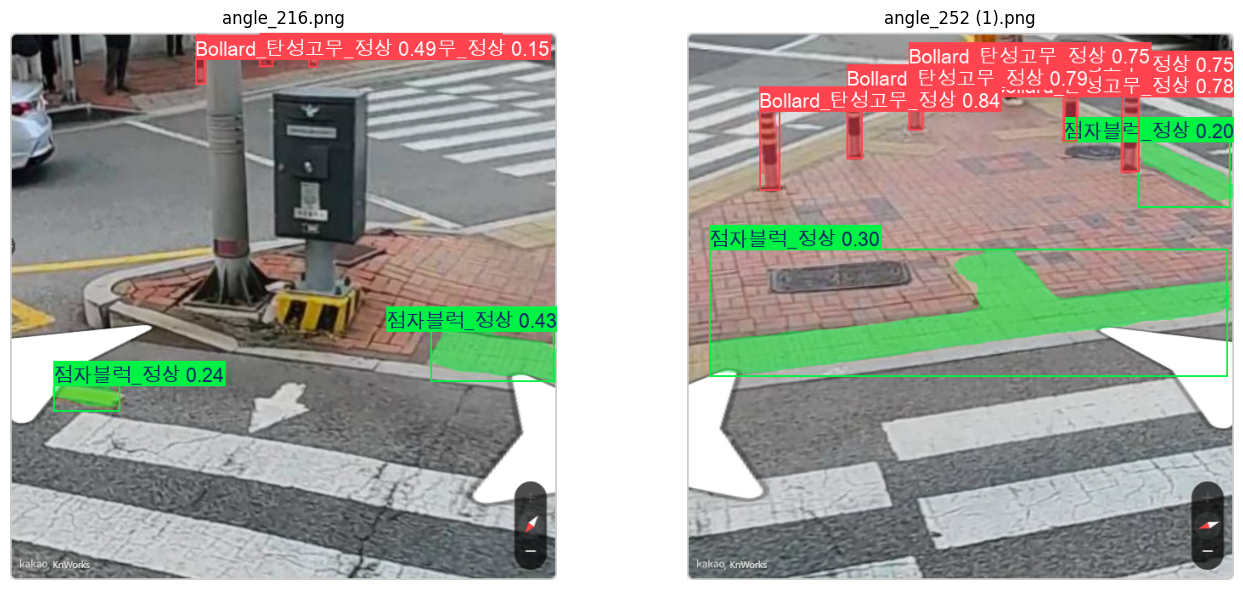

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 결과 이미지 다운로드 완료


In [18]:
# 테스트 셀 - Colab에 추가하세요
from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# best.pt 로드
# best_model = YOLO('/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/best.pt')
# best_model = YOLO('/content/drive/MyDrive/yolo_fine_runs/road_facility_finetune_v1/weights/best.pt')
best_model = YOLO('/content/drive/MyDrive/yolo_fine_v2_runs/road_facility_finetune_v1/weights/best.pt')

# 로컬 이미지 업로드
print("테스트할 이미지를 업로드하세요 (여러 장 가능)")
uploaded = files.upload()

# 추론 및 시각화
img_paths = list(uploaded.keys())
fig, axes = plt.subplots(1, len(img_paths), figsize=(7 * len(img_paths), 6))
if len(img_paths) == 1:
    axes = [axes]

for ax, img_path in zip(axes, img_paths):
    result  = best_model(img_path, conf=0.1)[0]
    plotted = result.plot()
    ax.imshow(plotted[:, :, ::-1])
    ax.set_title(img_path)
    ax.axis('off')

    # 탐지 결과 출력
    print(f'\n[{img_path}]')
    if result.masks is not None:
        for i, (box, cls) in enumerate(zip(result.boxes, result.boxes.cls)):
            cls_name = best_model.names[int(cls)]
            conf     = result.boxes.conf[i].item()
            print(f'  {cls_name}: {conf:.2f}')
    else:
        print('  탐지된 객체 없음')

plt.tight_layout()
plt.savefig('/content/test_result.png', dpi=150)
plt.show()

# 결과 이미지 다운로드
files.download('/content/test_result.png')
print('\n✅ 결과 이미지 다운로드 완료')

In [ ]:
# HuggingFace Hub에 모델 업로드 (선택)
HF_TOKEN = 'your_hf_token'          # ← 입력
HF_REPO  = 'your-username/road-facility-yolo11-seg'  # ← 입력

from huggingface_hub import HfApi
api = HfApi()
api.create_repo(HF_REPO, token=HF_TOKEN, exist_ok=True)
api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/yolo_runs/road_facility_seg_v1/weights/best.pt',
    path_in_repo='best.pt',
    repo_id=HF_REPO,
    token=HF_TOKEN,
)
print(f'✅ 업로드: https://huggingface.co/{HF_REPO}')